# Bonus_score: tidsplassering og informasjonsinnhold

Denne notebooken vurderer om `bonus_score` kan være en kandidat i den senere
prismodellen. Den er avgrenset til egen-skadeporteføljen og bruker bare
train-pool (2022–2023). 2024 leses ikke, slik at featurebeslutningen
ikke blir drevet av endelig testdata.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from src_descriptives.data_quality import build_variable_dictionary, clean_motor_data
from src_descriptives.own_damage_descriptives import (
    build_bonus_change_summary,
    build_bonus_history_strata,
    build_bonus_lagged_panel,
    build_bonus_transition_matrix,
    fit_bonus_timing_model,
    plot_bonus_change_summary,
    plot_bonus_history_strata,
    plot_bonus_transition_matrix,
)

DATA_PATH = Path("data/Dataset of motor insurance portfolio.csv")
DESCRIPTION_PATH = Path("data/Descriptive of variables.xlsx")
if not DATA_PATH.exists() or not DESCRIPTION_PATH.exists():
    raise FileNotFoundError(
        "Kjør notebooken fra prosjektroten slik at filene i data/ er tilgjengelige."
    )

## 1. Reproduserbart analysegrunnlag

Samme konservative rensing og kaskoscope som i hovednotebooken brukes her.
Positiv egen-skadepremie identifiserer aktiv dekning, og positiv eksponering
identifiserer poliseår med risiko. `train_pool` inneholder kun 2022–2023.

In [2]:
# Kun utviklingsårene leses; 2024-radene filtreres bort bit for bit og lagres aldri.
raw_data = pd.concat(
    chunk.loc[chunk["year"].isin([2022, 2023])]
    for chunk in pd.read_csv(
        DATA_PATH, sep=";", encoding="utf-8", low_memory=False, chunksize=100_000
    )
)
variable_dictionary = build_variable_dictionary()
data, cleaning_log = clean_motor_data(raw_data, variable_dictionary)
own_damage_mask = data["property_damage_premium"].gt(0) & data[
    "total_exposure"
].gt(0)
own_damage = data.loc[own_damage_mask].copy()
train_pool = own_damage.loc[own_damage["year"].isin([2022, 2023])].copy()
assert train_pool["year"].isin([2022, 2023]).all()
assert train_pool["property_damage_premium"].gt(0).all()
assert train_pool["total_exposure"].gt(0).all()
display(cleaning_log)
display(
    pd.Series(
        {
            "Poliseår i kaskoscope": len(own_damage),
            "Poliseår i train-pool (2022–2023)": len(train_pool),
            "Eksponering i train-pool": train_pool["total_exposure"].sum(),
        },
        name="Verdi",
    ).to_frame()
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,Verdi
Poliseår i kaskoscope,56084.000000
Poliseår i train-pool (2022–2023),56084.000000
Eksponering i train-pool,37904.443836


## 2. Tidsplassering av bonus_score

Kilden gir ingen eksakt *as-of*-dato for `bonus_score`. Vi kobler derfor bare
sammenhengende par `t-1 → t` for samme `insured_id`. G < N < B brukes bare i
denne diagnosen til å definere forbedring og forverring; i en modell skal
`bonus_score` fortsatt behandles kategorisk.

Dette er en observasjonsdiagnose, ikke kausal dokumentasjon. Den kan ikke i
seg selv bevise leakage eller leakage-fri timing.

,Verdi
Antall sammenhengende t-1 → t-par,18357


col_0,G,N,B
row_0,,,
G,17505,56,23
N,166,171,20
B,1,154,261


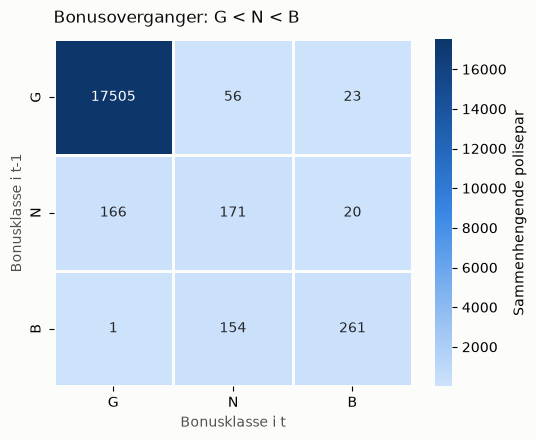

,skadedefinisjon,tidspunkt,gruppe,sammenhengende_par,forverret_prosent,forbedret_prosent
0,Egen skade,Skade i t-1,Ingen skade,16784,0.12,1.86
1,Egen skade,Skade i t-1,Minst én skade,1573,5.02,0.51
2,Egen skade,Skade i t,Ingen skade,15395,0.40,1.75
3,Egen skade,Skade i t,Minst én skade,2962,1.28,1.76
4,Alle skader,Skade i t-1,Ingen skade,15279,0.08,1.88
5,Alle skader,Skade i t-1,Minst én skade,3078,2.83,1.10
6,Alle skader,Skade i t,Ingen skade,13390,0.37,1.73
7,Alle skader,Skade i t,Minst én skade,4967,1.01,1.79


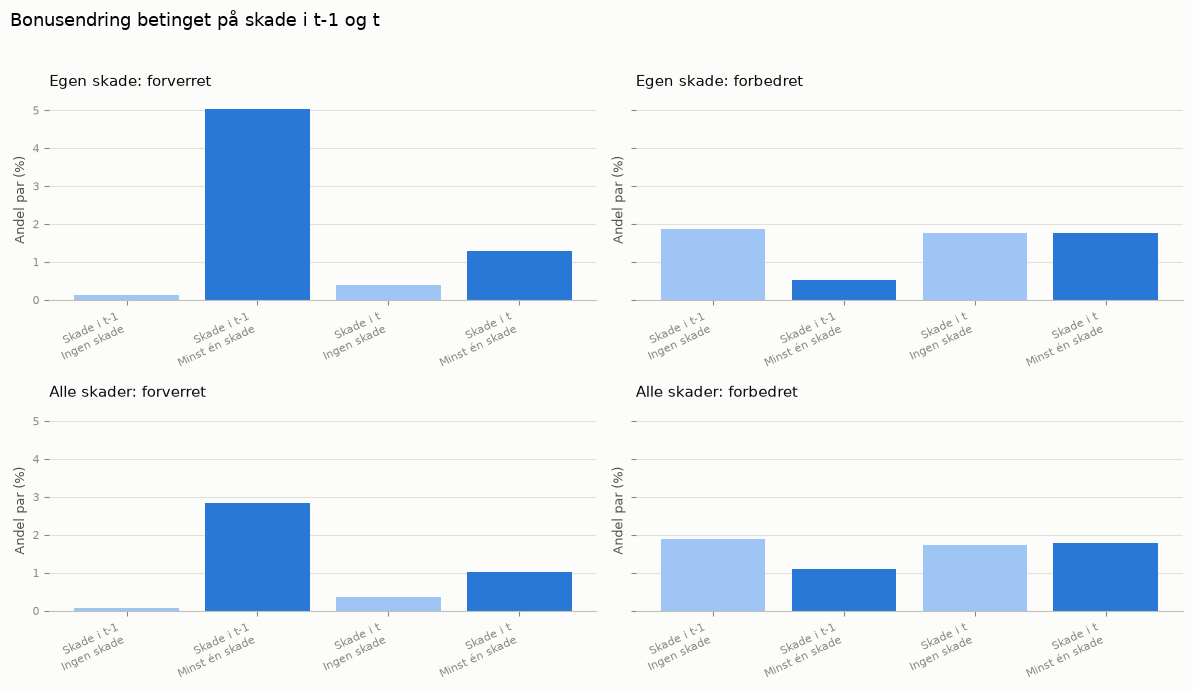

In [3]:
bonus_panel = build_bonus_lagged_panel(train_pool)
bonus_transition = build_bonus_transition_matrix(bonus_panel)
bonus_changes = build_bonus_change_summary(bonus_panel)
display(
    pd.Series(
        {"Antall sammenhengende t-1 → t-par": len(bonus_panel)}, name="Verdi"
    ).to_frame()
)
display(bonus_transition)
display(plot_bonus_transition_matrix(bonus_transition))
display(bonus_changes)
display(plot_bonus_change_summary(bonus_changes))

## 3. Multivariat timingdiagnose

Den logistiske diagnosen har bonusforverring i t som utfall og inkluderer
både lagget og samtidig antall egen-skader og alle skader, med kontroll for
bonusklasse i t-1. År tas med dersom det varierer. Her finnes bare overgangen
2022 → 2023 i den leakage-sikre train-poolen, så en årseffekt kan ikke
estimeres uten å bruke 2024. B er dårligste klasse og kan ikke forverres;
den holdes derfor utenfor risikosettet, men beholdes i overgangsmatrisen.

Odds ratio over én betyr høyere observert odds for bonusforverring, gitt de
andre leddene. Resultatet er en stabilitetssjekk, ikke kausal dokumentasjon.

In [4]:
bonus_timing_effects, bonus_timing_diagnostics, bonus_timing_formula = (
    fit_bonus_timing_model(bonus_panel)
)
display(bonus_timing_diagnostics)
display(bonus_timing_effects)
display(pd.Series({"Modellformel": bonus_timing_formula}, name="Verdi").to_frame())

,Verdi
sammenhengende_par_i_modell,17941
lagget_B_utelatt_strukturelt,416
bonusforverringer,99
forverring_prosent,0.551809
kalenderår_estimert,Nei; train-pool har bare overgang til 2023
konvergerte,True


,ledd,odds_ratio,nedre_95_prosent,øvre_95_prosent,p_verdi
0,Intercept,0.001,0.001,0.002,0.000
1,"C(bonus_score_lag, Treatment(reference='G'))[T.N]",19.704,10.716,36.228,0.000
2,property_claims_lag,1.285,1.004,1.645,0.047
3,property_claims,1.097,0.769,1.565,0.610
4,total_claims_lag,2.213,1.767,2.772,0.000
5,total_claims,1.215,0.901,1.637,0.202


,Verdi
Modellformel,"bonus_worsened_t ~ C(bonus_score_lag, Treatmen..."


In [5]:
lag_total_or = bonus_timing_effects.loc[
    bonus_timing_effects["ledd"].eq("total_claims_lag"), "odds_ratio"
].iloc[0]
current_total_or = bonus_timing_effects.loc[
    bonus_timing_effects["ledd"].eq("total_claims"), "odds_ratio"
].iloc[0]
timing_interpretation = pd.Series(
    {
        "Tolkning": (
            f"I {int(bonus_timing_diagnostics.loc['sammenhengende_par_i_modell', 'Verdi']):,} "
            f"par i risikosettet var odds ratio {lag_total_or:.2f} for én ekstra "
            f"lagget totalskade, mot {current_total_or:.2f} for samtidig totalskade. "
            "Sammen med intervallene i tabellen er dette konsistent med en lagget "
            "tolkning, men ikke et bevis på leakage-fri timing."
        )
    },
    name="Verdi",
).to_frame()
display(timing_interpretation)

,Verdi
Tolkning,"I 17,941 par i risikosettet var odds ratio 2.2..."


## 4. Informasjon utover eksplisitt ettårig skadehistorikk

Nåværende kaskofrekvens vises per bonusklasse innen strata av lagget totalt
skadeutfall og lagget egen-skadeutfall. Dette undersøker om scoren skiller
risiko blant poliser med lik, eksplisitt observert ettårig historikk. Den kan
fortsatt representere eldre skadehistorikk, underwriting-informasjon eller
uavklart timing.

,historikkdefinisjon,historikk_stratum,bonus_score,poliseår,eksponering,skadeantall_t,frekvens_t
0,Lagget total skadehistorikk,0 skader,G,14787,13914.4630,4152,0.2984
1,Lagget total skadehistorikk,0 skader,N,290,254.6356,117,0.4595
2,Lagget total skadehistorikk,0 skader,B,202,181.1836,123,0.6789
3,Lagget total skadehistorikk,1+ skade,G,2885,2637.6055,1154,0.4375
4,Lagget total skadehistorikk,1+ skade,N,91,77.9589,65,0.8338
5,Lagget total skadehistorikk,1+ skade,B,102,89.7644,76,0.8467
6,Lagget egen-skadehistorikk,0 skader,G,16240,15250.3781,4645,0.3046
7,Lagget egen-skadehistorikk,0 skader,N,316,278.5918,130,0.4666
8,Lagget egen-skadehistorikk,0 skader,B,228,204.9096,137,0.6686
9,Lagget egen-skadehistorikk,1+ skade,G,1432,1301.6904,661,0.5078


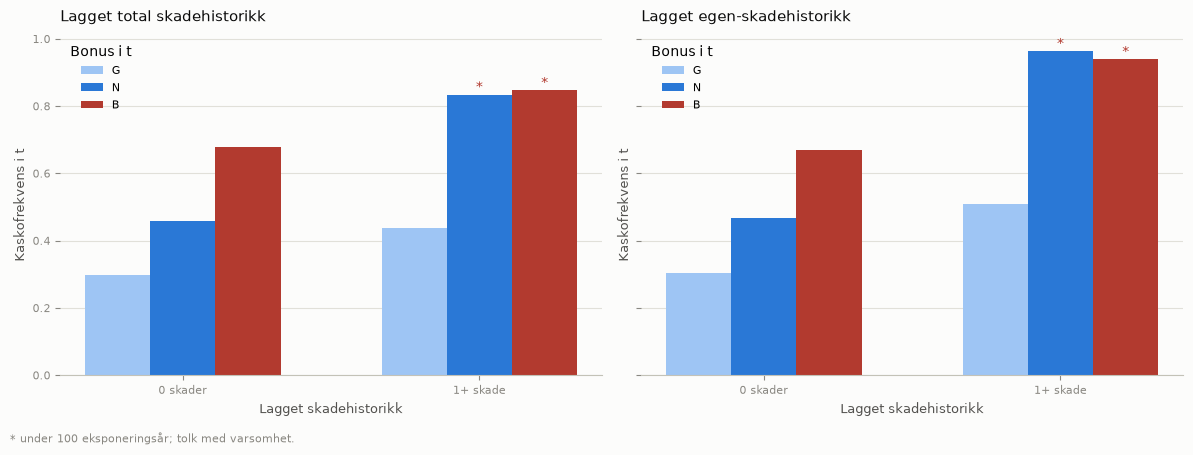

In [6]:
bonus_history_strata = build_bonus_history_strata(bonus_panel)
display(bonus_history_strata)
display(plot_bonus_history_strata(bonus_history_strata))

## 5. Konklusjon og regel for modelleringsfasen

Analysen tyder på at `bonus_score` inneholder informasjon utover den
eksplisitt observerte ettårige skadehistorikken. Timingmønsteret er mest
konsistent med at scoren bygger på tidligere års skader, ikke inneværende års
skadeutfall. Dette er ikke et endelig bevis på leakage-fri timing fordi
eksakt *as-of*-dato mangler.

`bonus_score` beholdes derfor foreløpig som kategorisk prediktorkandidat. I
modelleringsfasen skal den vurderes på nytt gjennom leakage-sikre
sammenligninger kun i train/CV: basis; basis + lagget historikk; basis +
bonus; og basis + begge, samt en obligatorisk sensitivitetsmodell uten bonus.
Teståret 2024 røres ikke før endelig evaluering.